# PageRank Development (Graph + Algorithm)
**Owner: Lalit** | Pipeline: graph → adjacency → transition matrix → Google matrix → power iteration → visualization

**Convention (project-wide):** `A[i,j]=1` if page i links to page j. Transition matrix `M` is *column-stochastic* (`M[i,j]` = P(j→i)). PageRank is a column vector with `PR = G @ PR`.

In [12]:
import sys; sys.path.insert(0, '../src')
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from graph import *
from pagerank import *
np.set_printoptions(precision=4, suppress=True)

## 1. Build the graph
`A→B, A→C, B→C, C→A, C→D, D→A`

nodes: ['A', 'B', 'C', 'D']
edges: [('A', 'B'), ('A', 'C'), ('B', 'C'), ('C', 'A'), ('C', 'D'), ('D', 'A')]


c:\Users\hps\matrix-eigenvalues-pagerank\.venv\Lib\site-packages\networkx\drawing\nx_pylab.py:1511: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  node_collection = ax.scatter(


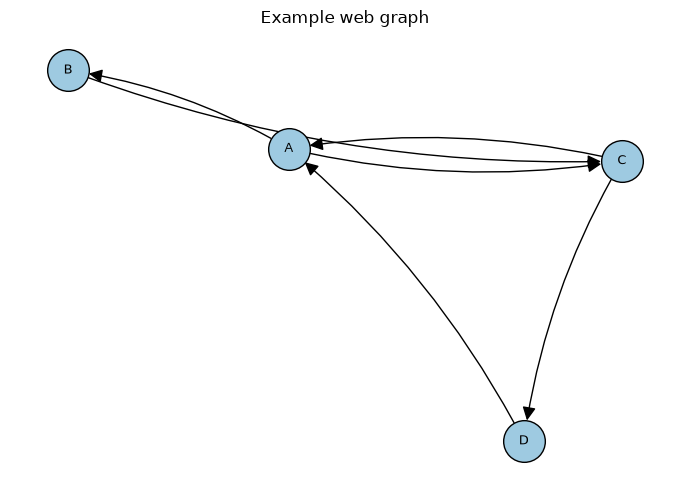

In [13]:
G = example_graph()
A, nodes = adjacency_matrix(G)
print('nodes:', nodes)
print('edges:', list(G.edges()))
fig = draw_graph(G, title='Example web graph')

## 2. Adjacency matrix
Row = source, column = destination.

In [14]:
print(A)

[[0. 1. 1. 0.]
 [0. 0. 1. 0.]
 [1. 0. 0. 1.]
 [1. 0. 0. 0.]]


## 3. Transition matrix
A has 2 out-links so each gets 1/2. C has 2 → 1/2 each. B and D have 1 out-link → probability 1. Columns sum to 1.

In [15]:
from power_iteration import transition_matrix

M = transition_matrix(A)
print(M)
print('column sums:', M.sum(axis=0))
# manual check: column A should be [0, .5, .5, 0]
assert np.allclose(M[:, 0], [0, .5, .5, 0])

[[0.  0.  0.5 1. ]
 [0.5 0.  0.  0. ]
 [0.5 1.  0.  0. ]
 [0.  0.  0.5 0. ]]
column sums: [1. 1. 1. 1.]


## 4. Dangling nodes
C has no out-links. Without a fix its column is all zeros and rank leaks out. We replace it with a uniform column `1/N` (surfer jumps to any page).

In [16]:
Gd = dangling_graph()
Ad, nd = adjacency_matrix(Gd)
print('Adjacency:\n', Ad)
print('\nNo fix:\n', transition_matrix(Ad, fix_dangling=False))
print('\nFixed:\n', transition_matrix(Ad))

Adjacency:
 [[0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 0.]]

No fix:
 [[0. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]]

Fixed:
 [[0.     0.     0.3333]
 [1.     0.     0.3333]
 [0.     1.     0.3333]]


## 5. Google matrix
$G = dM + \frac{1-d}{N}E$, with $E$ the all-ones matrix. Teleportation makes G positive, so the PageRank vector exists and is unique.

In [17]:
from networkx import google_matrix


d = 0.85
N = M.shape[0]
Gm = d * M + ((1 - d) / N) * np.ones_like(M)
print(Gm)
print('column sums:', Gm.sum(axis=0))

[[0.0375 0.0375 0.4625 0.8875]
 [0.4625 0.0375 0.0375 0.0375]
 [0.4625 0.8875 0.0375 0.0375]
 [0.0375 0.0375 0.4625 0.0375]]
column sums: [1. 1. 1. 1.]


## 6. Power iteration
Start from uniform `1/N`, repeat `PR ← G·PR` until `‖PR_new − PR‖₁ < ε`.

In [18]:
from power_iteration import eigen_check, power_iteration


pr, hist = power_iteration(Gm, tol=1e-10)
print('iterations:', len(hist))
for n, p in zip(nodes, pr):
    print(f'{n}: {p:.6f}')
print(eigen_check(Gm, pr))

iterations: 27
A: 0.324561
B: 0.175439
C: 0.324561
D: 0.175439
{'sums_to_1': True, 'columns_sum_to_1': True, 'residual ||G@pr - pr||_1': 3.9344971725086e-11}


## 7. Sanity check vs NetworkX (reference only, not our implementation)

In [19]:
ref = nx.pagerank(G, alpha=d, tol=1e-12, max_iter=1000)
print('max diff vs networkx:', max(abs(pr[i]-ref[n]) for i, n in enumerate(nodes)))

# Cross-check with direct eigenvector (Likith's eigenvalues.py will replace this)
w, v = np.linalg.eig(Gm)
k = np.argmax(w.real)
e = np.abs(v[:, k].real); e /= e.sum()
print('eigenvalue:', w[k].real, '| max diff vs eigenvector:', np.abs(e - pr).max())

max diff vs networkx: 6.67746413718362e-12
eigenvalue: 1.0000000000000004 | max diff vs eigenvector: 6.902645122153217e-12


## 8. Visualization
Node size and color ∝ PageRank.

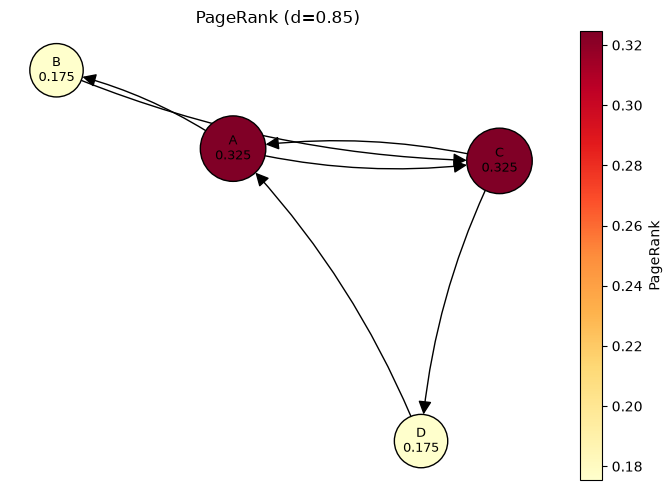

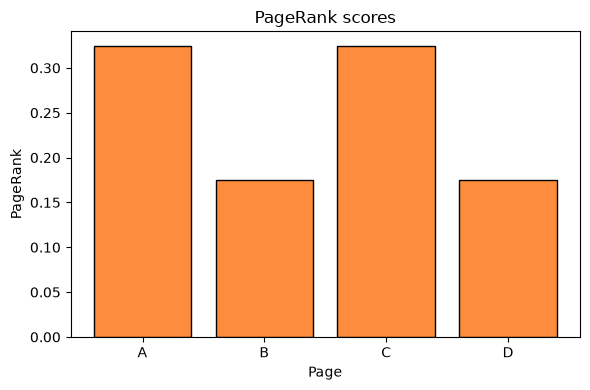

In [20]:
fig = draw_graph(G, pr, nodes, title='PageRank (d=0.85)', save_path='../results/graph_visualization.png')
fig2 = plot_pagerank_bars(nodes, pr, save_path='../results/pagerank_bars.png')

## 9. Convergence plot
Error vs iteration for different damping factors (log scale). Higher d → slower convergence.

d=0.5: 17 iterations
d=0.7: 22 iterations
d=0.85: 27 iterations
d=0.95: 31 iterations


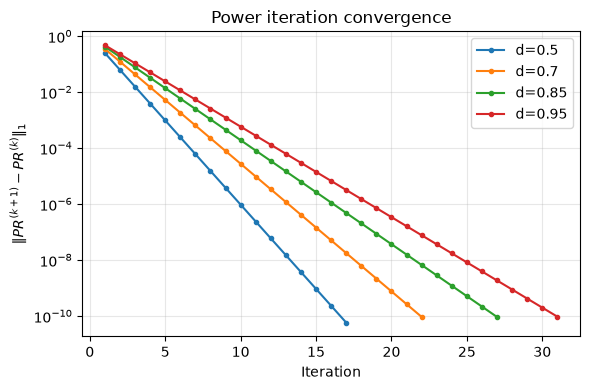

In [21]:
from power_iteration import *

hists, labels = [], []
for dd in [0.5, 0.7, 0.85, 0.95]:
    _, h, _ = pagerank(A, dd)
    hists.append(h); labels.append(f'd={dd}')
    print(f'd={dd}: {len(h)} iterations')
fig = plot_convergence(hists, labels, save_path='../results/convergence.png')

## 10. Other graph types
Spider trap, hub, star, cycle, chain, 6-node. Same pipeline works on all.

spider trap  iters=138   {'A': np.float64(0.038), 'B': np.float64(0.053), 'C': np.float64(0.471), 'D': np.float64(0.438)}
hub          iters=144   {0: np.float64(0.473), 1: np.float64(0.105), 2: np.float64(0.105), 3: np.float64(0.105), 4: np.float64(0.105), 5: np.float64(0.105)}
star         iters=143   {0: np.float64(0.476), 1: np.float64(0.434), 2: np.float64(0.03), 3: np.float64(0.03), 4: np.float64(0.03)}
cycle        iters=  1   {0: np.float64(0.2), 1: np.float64(0.2), 2: np.float64(0.2), 3: np.float64(0.2), 4: np.float64(0.2)}
chain        iters= 43   {0: np.float64(0.081), 1: np.float64(0.15), 2: np.float64(0.209), 3: np.float64(0.259), 4: np.float64(0.301)}
6-node       iters= 94   {'A': np.float64(0.256), 'B': np.float64(0.134), 'C': np.float64(0.181), 'D': np.float64(0.216), 'E': np.float64(0.102), 'F': np.float64(0.112)}


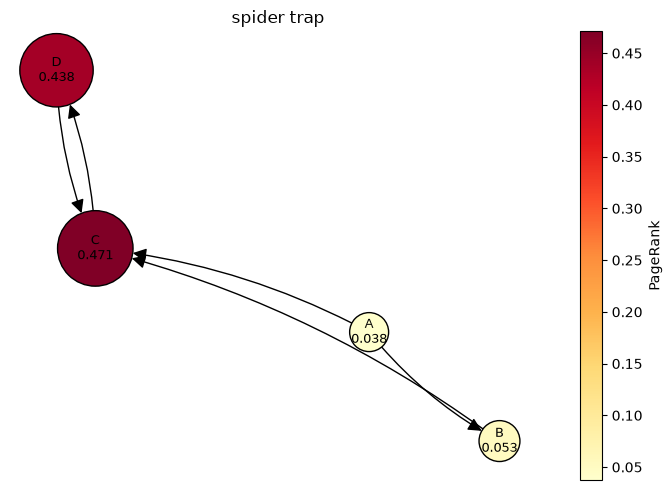

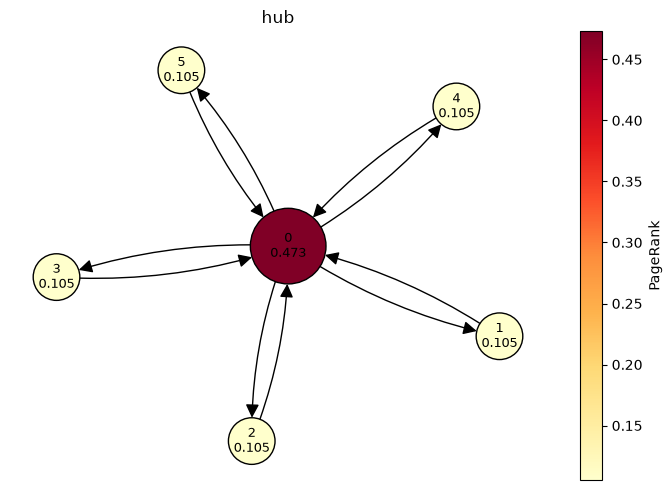

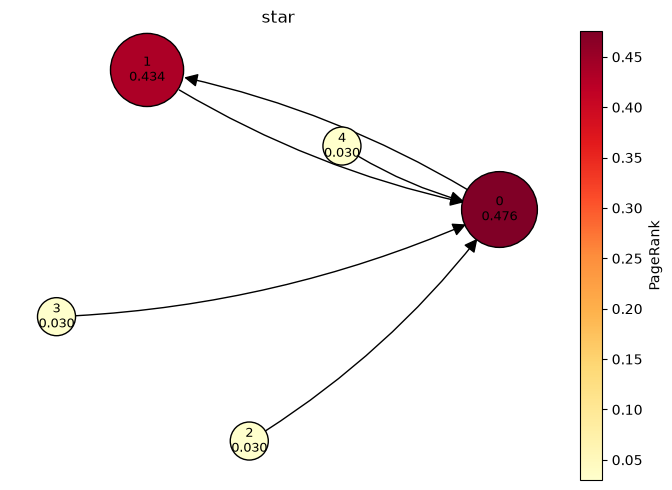

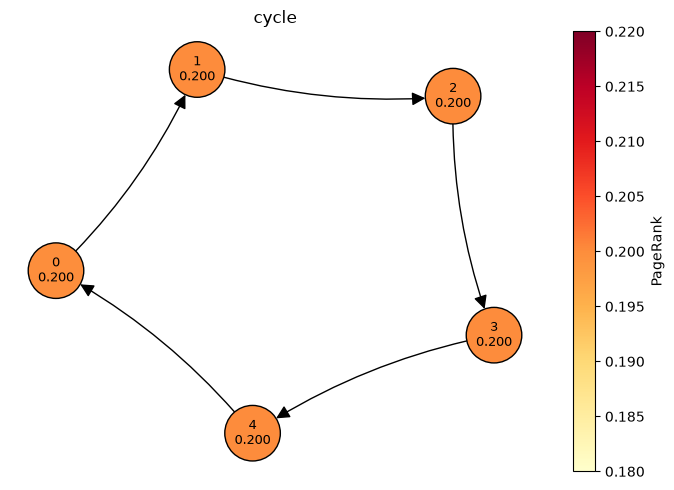

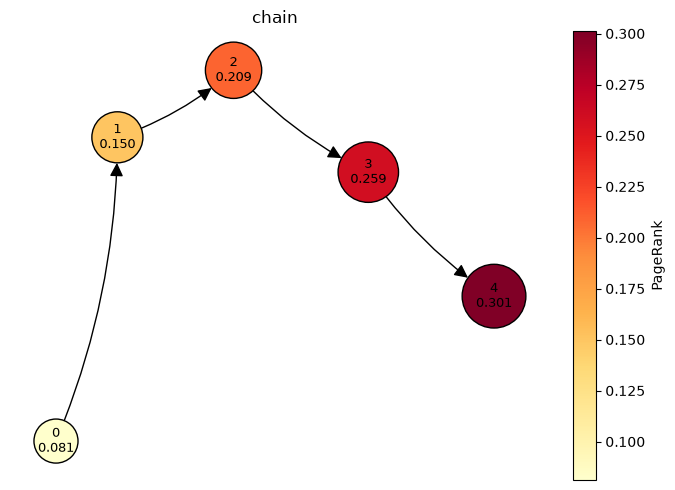

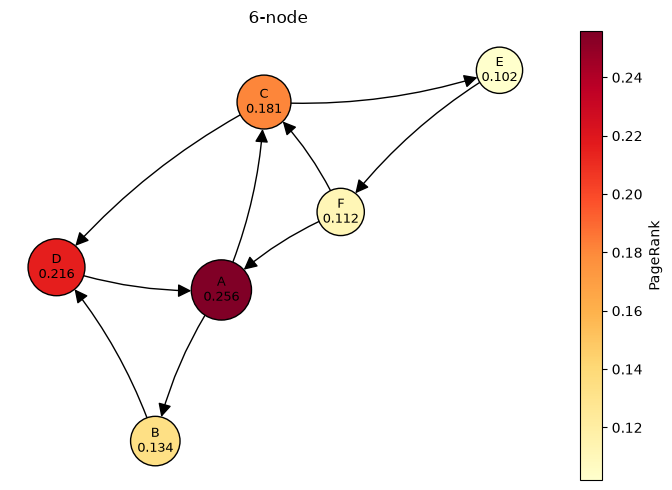

In [22]:
graphs = {'spider trap': spider_trap_graph(), 'hub': hub_graph(), 'star': star_graph(),
          'cycle': cycle_graph(), 'chain': chain_graph(), '6-node': six_node_graph()}
for name, g in graphs.items():
    Ag, ng = adjacency_matrix(g)
    p, h, Gg = pagerank(Ag, 0.85)
    print(f'{name:12s} iters={len(h):3d}  ', dict(zip(ng, p.round(3))))
    draw_graph(g, p, ng, title=name)